In [44]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.21.0


In [45]:
iris = load_iris()

X = iris.data
y = iris.target

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [46]:
print("Number of Samples :", X.shape[0])
print("Number of Features :", X.shape[1])
print("Number of Classes :", len(np.unique(y)))

Number of Samples : 150
Number of Features : 4
Number of Classes : 3


In [47]:
print("Feature Names\n")

for feature in iris.feature_names:
    print(feature)

Feature Names

sepal length (cm)
sepal width (cm)
petal length (cm)
petal width (cm)


In [48]:
print("Flower Classes\n")

for target in iris.target_names:
    print(target)

Flower Classes

setosa
versicolor
virginica


In [49]:
df = pd.DataFrame(X, columns=iris.feature_names)

df["Species"] = y

df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   Species            150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [51]:
species_names = {
    0: "Setosa",
    1: "Versicolor",
    2: "Virginica"
}

print(df["Species"].map(species_names).value_counts())

Species
Setosa        50
Versicolor    50
Virginica     50
Name: count, dtype: int64


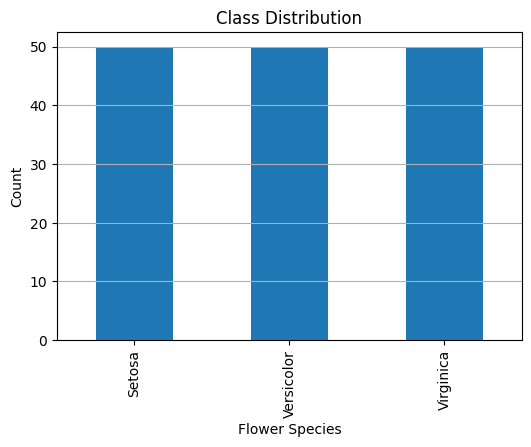

In [52]:
plt.figure(figsize=(6,4))

df["Species"].map(species_names).value_counts().plot(
    kind="bar"
)

plt.title("Class Distribution")

plt.xlabel("Flower Species")

plt.ylabel("Count")

plt.grid(axis="y")

plt.show()

In [53]:
sample = df.iloc[0]

print(sample)

sepal length (cm)    5.1
sepal width (cm)     3.5
petal length (cm)    1.4
petal width (cm)     0.2
Species              0.0
Name: 0, dtype: float64


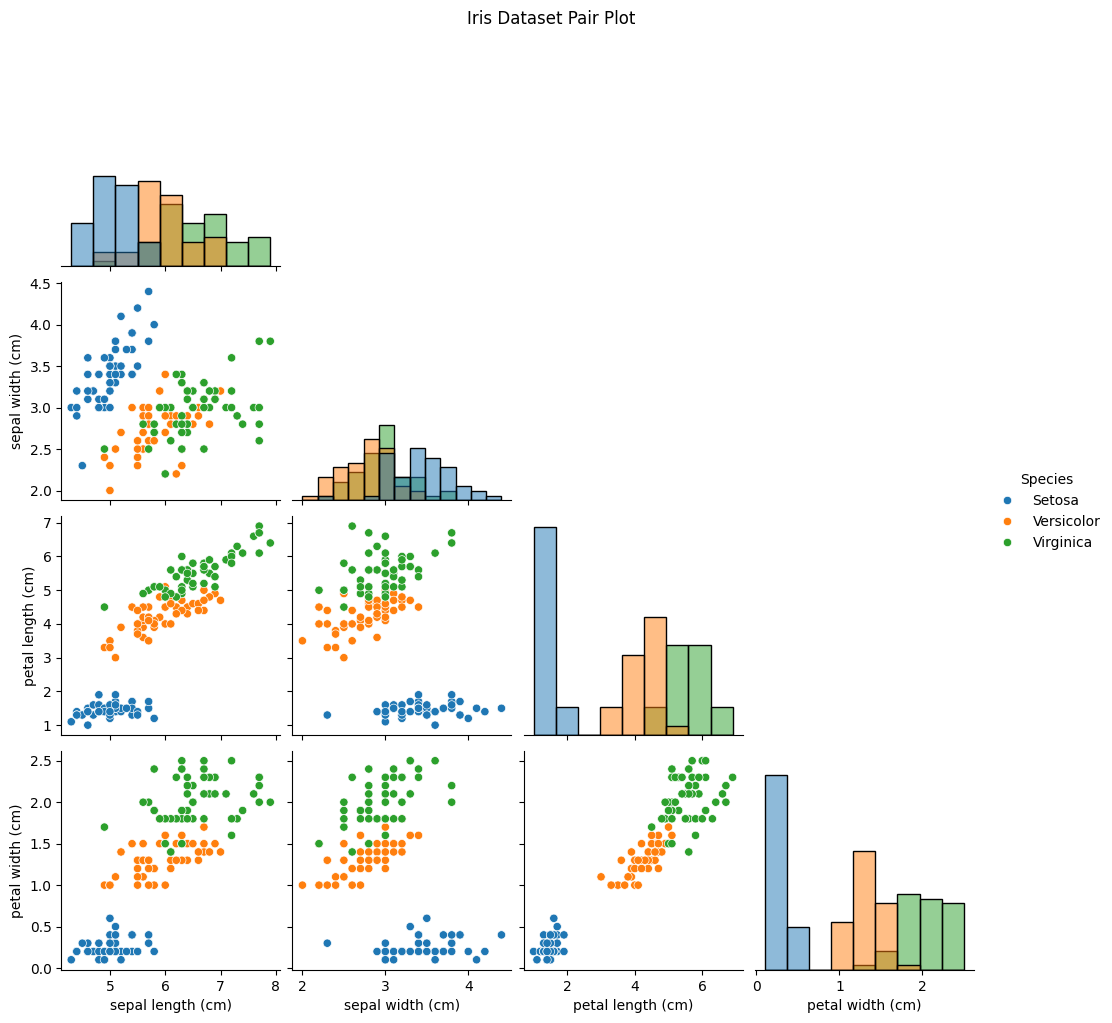

In [54]:
import seaborn as sns

# Create a copy with species names
df_plot = df.copy()
df_plot["Species"] = df_plot["Species"].map(species_names)

sns.pairplot(
    df_plot,
    hue="Species",
    diag_kind="hist",
    corner=True
)

plt.suptitle("Iris Dataset Pair Plot", y=1.02)
plt.show()

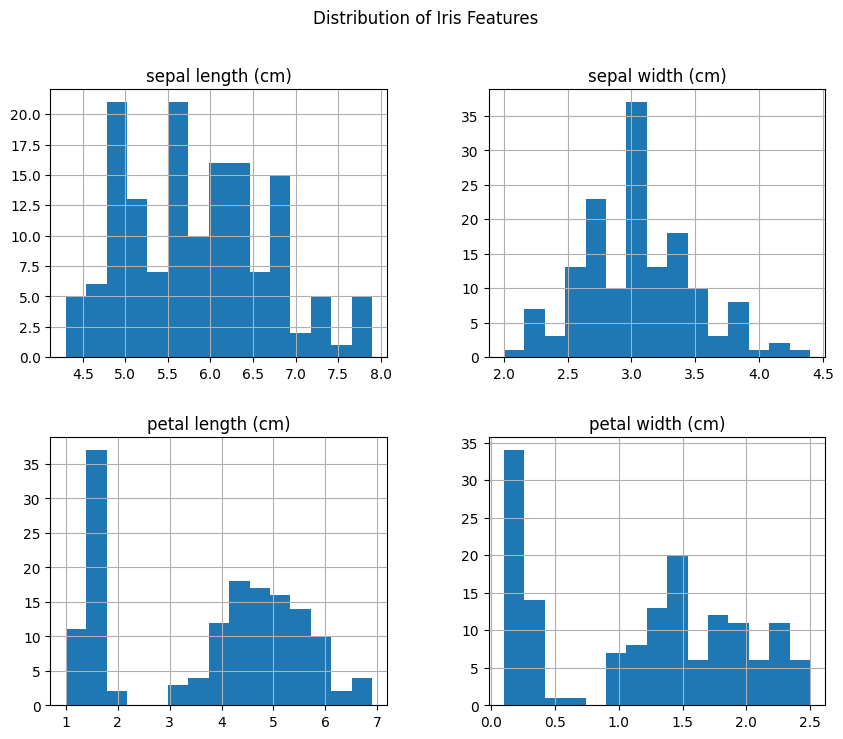

In [55]:
df.iloc[:,0:4].hist(
    figsize=(10,8),
    bins=15
)

plt.suptitle("Distribution of Iris Features")

plt.show()

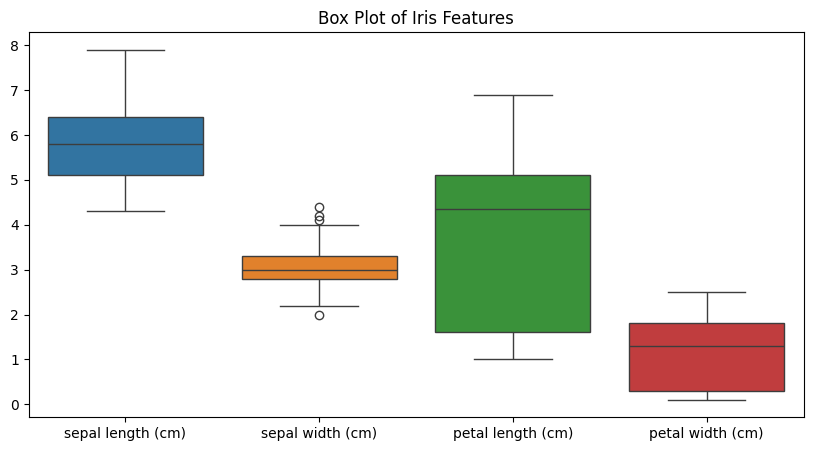

In [56]:
plt.figure(figsize=(10,5))

sns.boxplot(data=df.iloc[:,0:4])

plt.title("Box Plot of Iris Features")

plt.show()

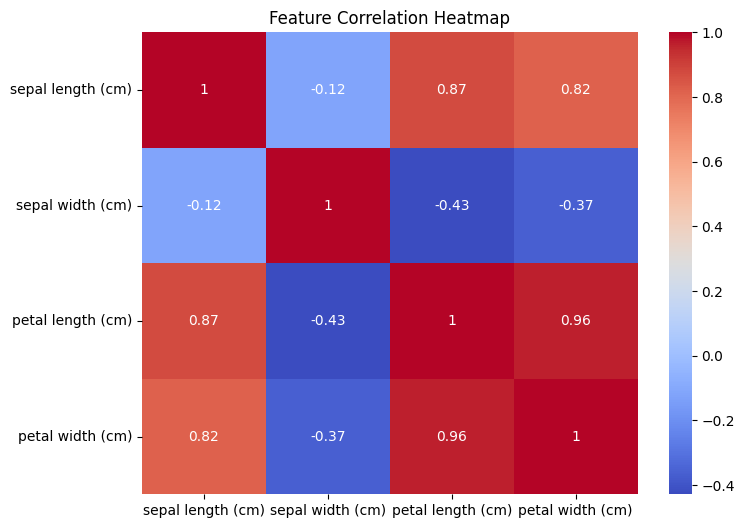

In [57]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.iloc[:,0:4].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Feature Correlation Heatmap")

plt.show()

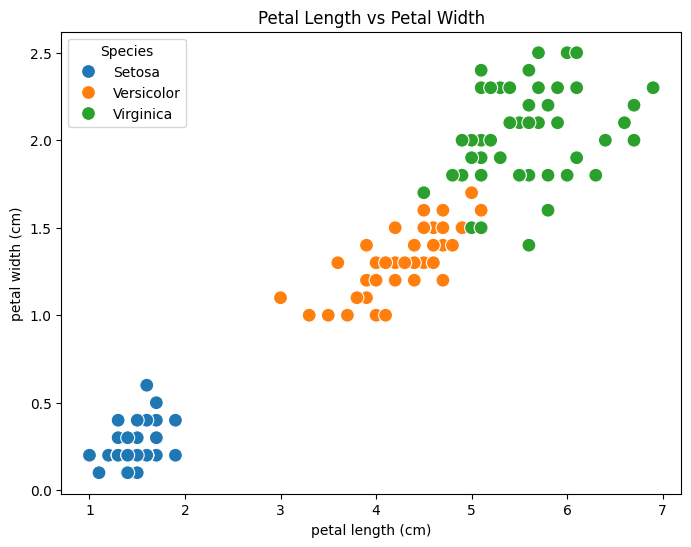

In [58]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df_plot,
    x="petal length (cm)",
    y="petal width (cm)",
    hue="Species",
    s=100
)

plt.title("Petal Length vs Petal Width")

plt.show()

In [59]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Shape :", X_train.shape)
print("Testing Shape :", X_test.shape)

Training Shape : (120, 4)
Testing Shape : (30, 4)


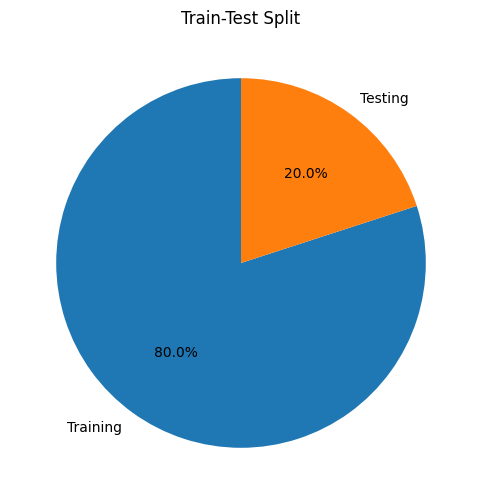

In [60]:
labels = ["Training","Testing"]

sizes = [len(X_train),len(X_test)]

plt.figure(figsize=(6,6))

plt.pie(
    sizes,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Train-Test Split")

plt.show()

In [61]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

print("Feature Scaling Completed")

Feature Scaling Completed


In [62]:
before = pd.DataFrame(X).iloc[:5]

after = pd.DataFrame(X_train).iloc[:5]

print("Before Scaling")
display(before)

print("After Scaling")
display(after)

Before Scaling


,0,1,2,3
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


After Scaling


,0,1,2,3
0,-1.721568,-0.332101,-1.345722,-1.323276
1,-1.124492,-1.227655,0.414505,0.651763
2,1.144395,-0.555990,0.584850,0.256755
3,-1.124492,0.115676,-1.288941,-1.454945
4,-0.408002,-1.227655,0.130598,0.125086


In [63]:
model = Sequential([

    Dense(
        16,
        activation="relu",
        input_shape=(4,)
    ),

    Dense(
        8,
        activation="relu"
    ),

    Dense(
        3,
        activation="softmax"
    )

])

c:\Users\Lenovo\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [64]:
model.summary()

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_45 (Dense)                │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_47 (Dense)                │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 243 (972.00 B)

 Trainable params: 243 (972.00 B)

 Non-trainable params: 0 (0.00 B)

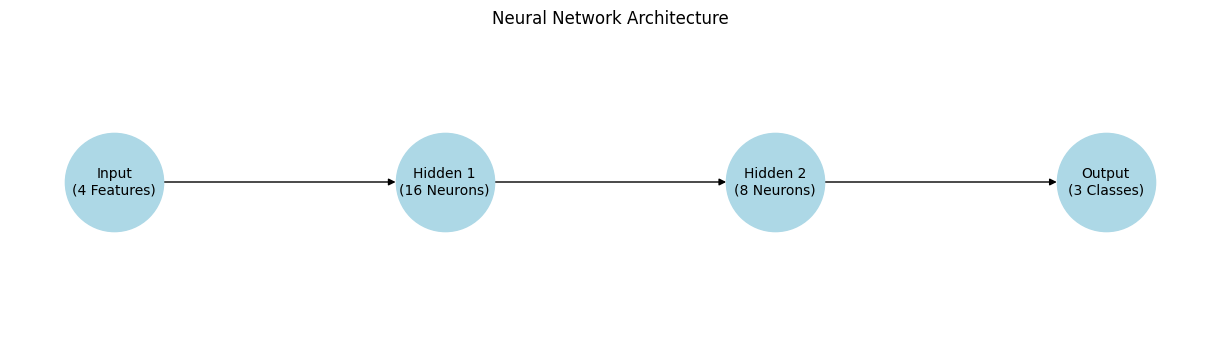

In [66]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.DiGraph()

# Layers
G.add_node("Input\n(4 Features)")
G.add_node("Hidden 1\n(16 Neurons)")
G.add_node("Hidden 2\n(8 Neurons)")
G.add_node("Output\n(3 Classes)")

# Connections
G.add_edge("Input\n(4 Features)", "Hidden 1\n(16 Neurons)")
G.add_edge("Hidden 1\n(16 Neurons)", "Hidden 2\n(8 Neurons)")
G.add_edge("Hidden 2\n(8 Neurons)", "Output\n(3 Classes)")

# Position
pos = {
    "Input\n(4 Features)": (0, 0),
    "Hidden 1\n(16 Neurons)": (2, 0),
    "Hidden 2\n(8 Neurons)": (4, 0),
    "Output\n(3 Classes)": (6, 0)
}

plt.figure(figsize=(12,3))

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=5000,
    node_color="lightblue",
    font_size=10,
    arrows=True
)

plt.title("Neural Network Architecture")

plt.show()

In [75]:
optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.001
)

model.compile(
    optimizer=optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model Compiled Successfully")

Model Compiled Successfully


In [76]:
from IPython.display import Markdown

display(Markdown("""
# Forward Propagation


Input Features

  │

  ▼

Hidden Layer 1

  │

  ▼

ReLU Activation

  │

  ▼

Hidden Layer 2

  │

  ▼

ReLU Activation

  │

  ▼

Output Layer

  │

  ▼

Softmax

  │

  ▼

Prediction

"""))


# Forward Propagation


Input Features

  │

  ▼

Hidden Layer 1

  │

  ▼

ReLU Activation

  │

  ▼

Hidden Layer 2

  │

  ▼

ReLU Activation

  │

  ▼

Output Layer

  │

  ▼

Softmax

  │

  ▼

Prediction



In [70]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 10s 394ms/step - accuracy: 0.4271 - loss: 1.1377 - val_accuracy: 0.5000 - val_loss: 1.0199
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.4271 - loss: 1.1151 - val_accuracy: 0.5417 - val_loss: 1.0006
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.4479 - loss: 1.0940 - val_accuracy: 0.5833 - val_loss: 0.9824
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.4688 - loss: 1.0731 - val_accuracy: 0.6250 - val_loss: 0.9651
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.4896 - loss: 1.0535 - val_accuracy: 0.6250 - val_loss: 0.9492
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.5104 - loss: 1.0357 - val_accuracy: 0.6667 - val_loss: 0.9336
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.5208 - loss: 1.0169 - val_accuracy: 0.6667 - val_loss: 0.9190
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.5208 - loss: 1.0001 - val_accuracy: 0.6667 - val_loss: 0.904

In [72]:
from IPython.display import clear_output
import time

steps = [
    "Input Data",
    "Forward Propagation",
    "Prediction",
    "Loss Calculation",
    "Backpropagation",
    "Weight Update",
    "Next Epoch"
]

for step in steps:
    clear_output(wait=True)
    print("=" * 40)
    print(step)
    print("=" * 40)
    time.sleep(1)

Next Epoch


In [74]:
from IPython.display import Markdown

display(Markdown("""
# Backpropagation
 Prediction

  │

  ▼

Calculate Loss

  │

  ▼

Find Error

  │

  ▼

Compute Gradient

  │

  ▼

Update Weights

  │

  ▼

Repeat

"""))


# Backpropagation
 Prediction

  │

  ▼

Calculate Loss

  │

  ▼

Find Error

  │

  ▼

Compute Gradient

  │

  ▼

Update Weights

  │

  ▼

Repeat



In [77]:
from IPython.display import Markdown

display(Markdown("""
# Training Cycle

           FORWARD

Input

↓

Hidden Layer

↓

Output

↓

Prediction

↓

Loss

══════════════════════════════

    BACKPROPAGATION

Loss

↑

Output

↑

Hidden Layer

↑

Input

(Update Weights)

"""))


# Training Cycle

           FORWARD

Input

↓

Hidden Layer

↓

Output

↓

Prediction

↓

Loss

══════════════════════════════

    BACKPROPAGATION

Loss

↑

Output

↑

Hidden Layer

↑

Input

(Update Weights)



In [78]:
loss, accuracy = model.evaluate(
    X_test,
    y_test
)

print("Loss :", loss)
print("Accuracy :", accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 415ms/step - accuracy: 0.8000 - loss: 0.4878
Loss : 0.4878387749195099
Accuracy : 0.800000011920929


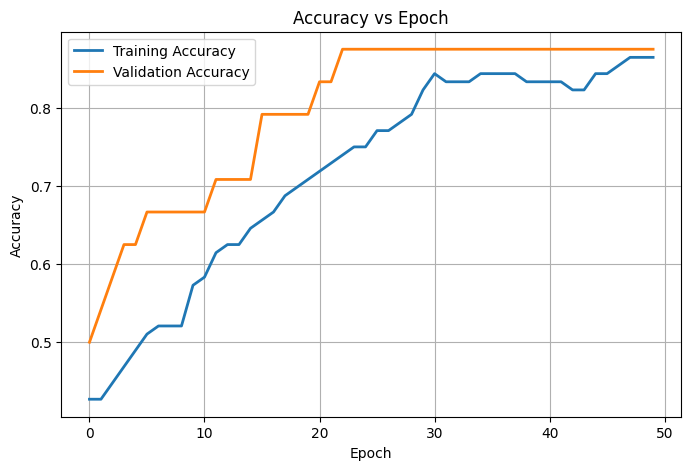

In [79]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy",
    linewidth=2
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy",
    linewidth=2
)

plt.title("Accuracy vs Epoch")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.grid(True)

plt.show()

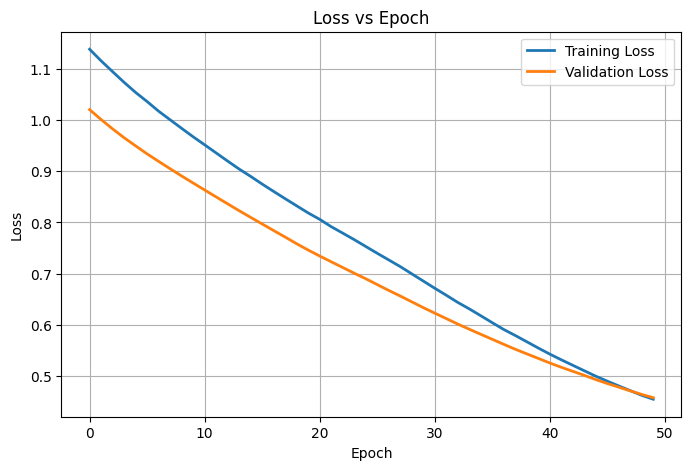

In [80]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history["loss"],
    label="Training Loss",
    linewidth=2
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss",
    linewidth=2
)

plt.title("Loss vs Epoch")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.show()

In [81]:
weights_before = model.layers[0].get_weights()[0].copy()

print(weights_before[:5])

[[-0.05408891 -0.2927414   0.08681584  0.2735768   0.20035341 -0.5231107
   0.4151532  -0.41904518 -0.17609245 -0.46269986  0.1554803   0.20936991
   0.45310012 -0.11008802  0.31084114  0.41022465]
 [-0.28633955  0.06435535  0.35332826  0.48652995 -0.17615053  0.61289567
  -0.2503753  -0.17381604 -0.08340649  0.5447815  -0.08328864 -0.0781917
   0.04126488 -0.644369    0.4353622   0.4354877 ]
 [ 0.24219385  0.44781342  0.45667246  0.13402599 -0.47568312 -0.3554609
   0.54788274 -0.23186798  0.11275081  0.31473365 -0.12200382 -0.30856985
   0.22557801  0.0623845  -0.63035023  0.42924353]
 [ 0.05240094 -0.08453964  0.37479046  0.05310924 -0.39340225 -0.44655558
  -0.27470085  0.39584267 -0.51032823  0.18427786 -0.37826398  0.4999557
   0.56437135 -0.02135611  0.05138726 -0.40004462]]


In [82]:
weights_after = model.layers[0].get_weights()[0]

print(weights_after[:5])

[[-0.05408891 -0.2927414   0.08681584  0.2735768   0.20035341 -0.5231107
   0.4151532  -0.41904518 -0.17609245 -0.46269986  0.1554803   0.20936991
   0.45310012 -0.11008802  0.31084114  0.41022465]
 [-0.28633955  0.06435535  0.35332826  0.48652995 -0.17615053  0.61289567
  -0.2503753  -0.17381604 -0.08340649  0.5447815  -0.08328864 -0.0781917
   0.04126488 -0.644369    0.4353622   0.4354877 ]
 [ 0.24219385  0.44781342  0.45667246  0.13402599 -0.47568312 -0.3554609
   0.54788274 -0.23186798  0.11275081  0.31473365 -0.12200382 -0.30856985
   0.22557801  0.0623845  -0.63035023  0.42924353]
 [ 0.05240094 -0.08453964  0.37479046  0.05310924 -0.39340225 -0.44655558
  -0.27470085  0.39584267 -0.51032823  0.18427786 -0.37826398  0.4999557
   0.56437135 -0.02135611  0.05138726 -0.40004462]]


In [87]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

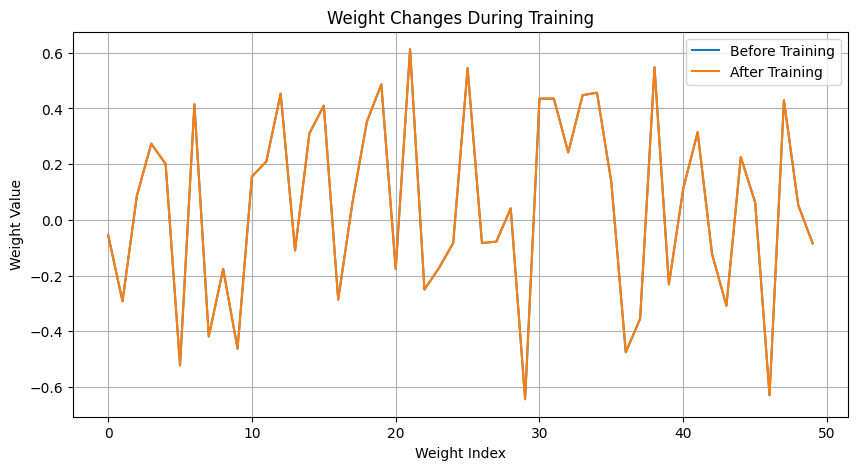

In [84]:
plt.figure(figsize=(10,5))

plt.plot(
    weights_before.flatten()[:50],
    label="Before Training"
)

plt.plot(
    weights_after.flatten()[:50],
    label="After Training"
)

plt.title("Weight Changes During Training")

plt.xlabel("Weight Index")

plt.ylabel("Weight Value")

plt.legend()

plt.grid(True)

plt.show()

In [85]:
# Predict probabilities
y_pred_prob = model.predict(X_test)

# Convert probabilities to class labels
y_pred = np.argmax(y_pred_prob, axis=1)

print("First 10 Predictions:")
print(y_pred[:10])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 365ms/step
First 10 Predictions:
[0 2 1 1 0 2 0 0 2 1]


<Figure size 600x600 with 0 Axes>

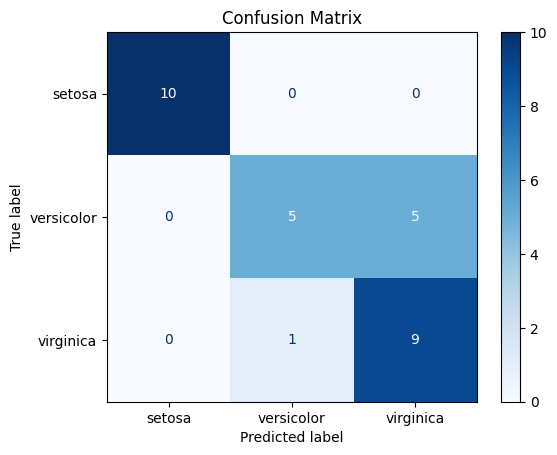

In [88]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=iris.target_names
)

plt.figure(figsize=(6,6))

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

In [89]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=iris.target_names
    )
)

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      0.50      0.62        10
   virginica       0.64      0.90      0.75        10

    accuracy                           0.80        30
   macro avg       0.83      0.80      0.79        30
weighted avg       0.83      0.80      0.79        30



In [90]:
sample = X_test[0].reshape(1,-1)

prediction = model.predict(sample)

predicted_class = np.argmax(prediction)

print("Predicted Flower :",
      iris.target_names[predicted_class])

print("Actual Flower :",
      iris.target_names[y_test[0]])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step
Predicted Flower : setosa
Actual Flower : setosa


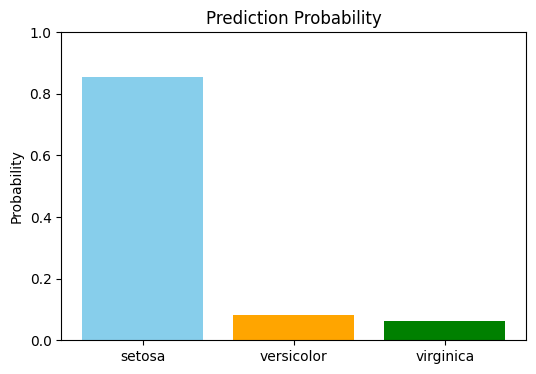

In [91]:
labels = iris.target_names

prob = prediction[0]

plt.figure(figsize=(6,4))

plt.bar(
    labels,
    prob,
    color=["skyblue","orange","green"]
)

plt.title("Prediction Probability")

plt.ylabel("Probability")

plt.ylim(0,1)

plt.show()

In [92]:
learning_rates = [0.1,0.01,0.001,0.0001]

results = []

for lr in learning_rates:

    temp_model = Sequential([

        Dense(16,activation="relu",input_shape=(4,)),

        Dense(8,activation="relu"),

        Dense(3,activation="softmax")

    ])

    temp_model.compile(

        optimizer=tf.keras.optimizers.Adam(
            learning_rate=lr
        ),

        loss="sparse_categorical_crossentropy",

        metrics=["accuracy"]

    )

    temp_model.fit(
        X_train,
        y_train,
        epochs=20,
        verbose=0
    )

    loss,acc = temp_model.evaluate(
        X_test,
        y_test,
        verbose=0
    )

    results.append([lr,acc])

learning_df = pd.DataFrame(
    results,
    columns=["Learning Rate","Accuracy"]
)

learning_df

c:\Users\Lenovo\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


,Learning Rate,Accuracy
0,0.1000,0.966667
1,0.0100,0.933333
2,0.0010,0.733333
3,0.0001,0.400000


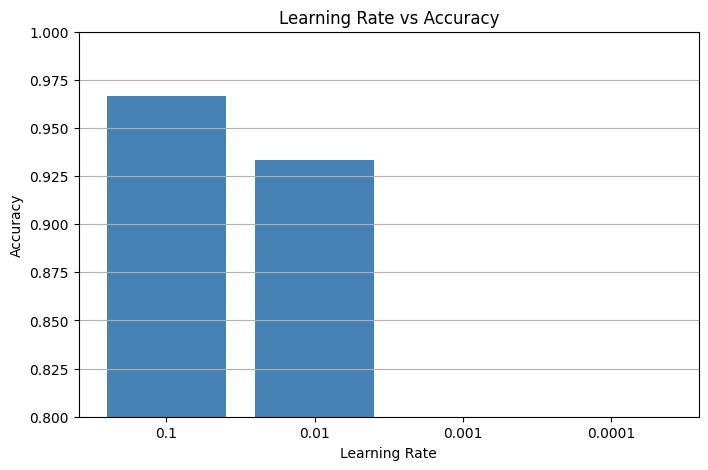

In [93]:
plt.figure(figsize=(8,5))

plt.bar(
    learning_df["Learning Rate"].astype(str),
    learning_df["Accuracy"],
    color="steelblue"
)

plt.title("Learning Rate vs Accuracy")

plt.xlabel("Learning Rate")

plt.ylabel("Accuracy")

plt.ylim(0.8,1.0)

plt.grid(axis="y")

plt.show()

In [94]:
epochs = [10,30,50,100]

epoch_result = []

for ep in epochs:

    temp_model = Sequential([

        Dense(16,activation="relu",input_shape=(4,)),

        Dense(8,activation="relu"),

        Dense(3,activation="softmax")

    ])

    temp_model.compile(

        optimizer="adam",

        loss="sparse_categorical_crossentropy",

        metrics=["accuracy"]

    )

    temp_model.fit(
        X_train,
        y_train,
        epochs=ep,
        verbose=0
    )

    loss,acc = temp_model.evaluate(
        X_test,
        y_test,
        verbose=0
    )

    epoch_result.append([ep,acc])

epoch_df = pd.DataFrame(
    epoch_result,
    columns=["Epochs","Accuracy"]
)

epoch_df

c:\Users\Lenovo\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


,Epochs,Accuracy
0,10,0.666667
1,30,0.866667
2,50,0.833333
3,100,0.900000


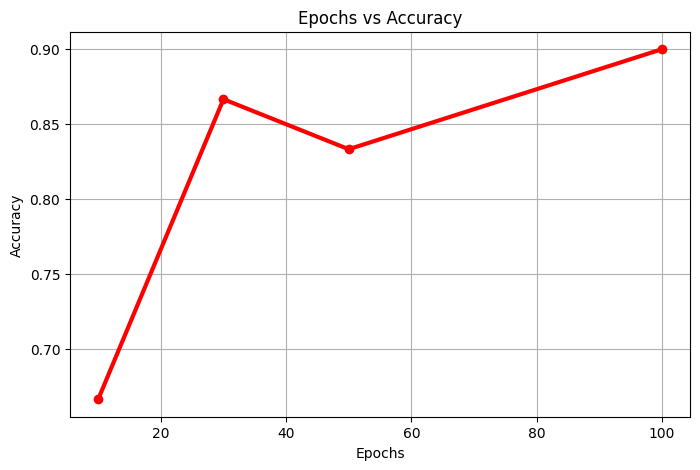

In [95]:
plt.figure(figsize=(8,5))

plt.plot(
    epoch_df["Epochs"],
    epoch_df["Accuracy"],
    marker="o",
    linewidth=3,
    color="red"
)

plt.title("Epochs vs Accuracy")

plt.xlabel("Epochs")

plt.ylabel("Accuracy")

plt.grid(True)

plt.show()

In [96]:
print("\nLearning Rate Analysis")
display(learning_df)

print("\nEpoch Analysis")
display(epoch_df)


Learning Rate Analysis


,Learning Rate,Accuracy
0,0.1000,0.966667
1,0.0100,0.933333
2,0.0010,0.733333
3,0.0001,0.400000



Epoch Analysis


,Epochs,Accuracy
0,10,0.666667
1,30,0.866667
2,50,0.833333
3,100,0.900000
